In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import nltk
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
#reading data
df = pd.read_csv(r'C:/Users/user/OneDrive/Documents/Sentiment_analysis/Comments for_Threads.csv')
df.drop(columns='Unnamed: 0')

,#Tags,thread,Discussion
0,IndianMarket,Local brands in Indian market,Drink Pappusi with Ovary Chocolate Biscuits. W...
1,IndianMarket,Does it really make sense for a trader of Indi...,There is something called Purchasing Power Par...
2,IndianMarket,Popular protein supplements sold in the Indian...,"There's a youtube channel named ""Trustified"" r..."
3,IndianMarket,Reputable Online Native Owned Jewelry Sellers,NaN
4,IndianMarket,"The day Boomer hits Rs2, Indian market will crash",its size/quantity would reduce first before in...
...,...,...,...
852,EconomicReformsIndia,Economic Reforms in India,NaN
853,EconomicReformsIndia,"""Economic Challenges and Reform Initiatives in...",NaN
854,EconomicReformsIndia,India’s Economic Reforms: New Energy along a P...,Submission statement:\nUS surpasses China as I...
855,EconomicReformsIndia,"""Economic Challenges and Reform Initiatives in...",NaN


In [5]:
#Exploratory Data Analysis
#Random value for thread and the comment section on reddit, for the search #IndianEconomy
Has_tag = df['#Tags'][105]
example_thread = df['thread'][105]
example_discussion = df['Discussion'][105]

# Has_tag
example_thread
# eample_discussion

'Nifty closes below 22,000, and Sensex tanks over 1,000 pts.'

In [6]:
nltk.word_tokenize(example_thread)


['Nifty',
 'closes',
 'below',
 '22,000',
 ',',
 'and',
 'Sensex',
 'tanks',
 'over',
 '1,000',
 'pts',
 '.']

In [7]:
nltk.word_tokenize(example_discussion)
len(nltk.word_tokenize(example_discussion))

243

In [8]:
#Trying Vader sentiment analyser on the example thread and discussion

nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [9]:
sia.polarity_scores(example_discussion)

{'neg': 0.069, 'neu': 0.818, 'pos': 0.114, 'compound': 0.8272}

In [10]:
from tqdm.notebook import tqdm

In [11]:
df.reset_index(inplace = True)
# df.drop(columns=['level_0','Unnamed: 0'],inplace=True)

# Running sentimment Analyzer on all the Threads
res = {}
for i, row in tqdm(df.iterrows(), total = len(df)):
    text = row['thread']
    id =row['index']
    res[id] = sia.polarity_scores(text)

  0%|          | 0/857 [00:00<?, ?it/s]

In [12]:
p_df = pd.DataFrame(res)

In [13]:
vaders = p_df.T
vaders = vaders.reset_index()
vaders= df.merge(vaders,how = 'left')

In [14]:
df['Discussion']=df['Discussion'].apply(lambda x:str(x))

In [15]:
df

,index,Unnamed: 0,#Tags,thread,Discussion
0,0,0,IndianMarket,Local brands in Indian market,Drink Pappusi with Ovary Chocolate Biscuits. W...
1,1,1,IndianMarket,Does it really make sense for a trader of Indi...,There is something called Purchasing Power Par...
2,2,2,IndianMarket,Popular protein supplements sold in the Indian...,"There's a youtube channel named ""Trustified"" r..."
3,3,3,IndianMarket,Reputable Online Native Owned Jewelry Sellers,nan
4,4,4,IndianMarket,"The day Boomer hits Rs2, Indian market will crash",its size/quantity would reduce first before in...
...,...,...,...,...,...
852,852,852,EconomicReformsIndia,Economic Reforms in India,nan
853,853,853,EconomicReformsIndia,"""Economic Challenges and Reform Initiatives in...",nan
854,854,854,EconomicReformsIndia,India’s Economic Reforms: New Energy along a P...,Submission statement:\nUS surpasses China as I...
855,855,855,EconomicReformsIndia,"""Economic Challenges and Reform Initiatives in...",nan


In [16]:
Ind_market =df[df['#Tags']=='IndianMarket']

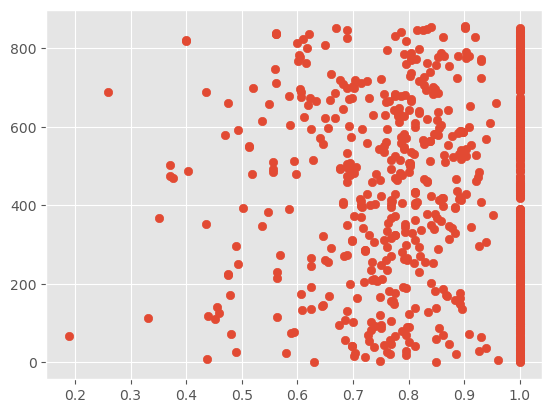

In [17]:
# plt.scatter(x=vaders['compound'],y=vaders['index'])
plt.scatter(x=vaders['neu'],y=vaders['index'])
# plt.plot(Ind_market['neg'])
# plt.plot(Ind_market['neu'])

In [18]:
RES = {}
for i, row in tqdm(df.iterrows(), total = len(df)):
    text = row['Discussion']
    id =row['index']
    RES[id] = sia.polarity_scores(text)

Vad = pd.DataFrame(RES)

  0%|          | 0/857 [00:00<?, ?it/s]

In [19]:
Vad = Vad.T
Vad.reset_index(inplace=True)
Vad= df.merge(Vad,how = 'left')

In [20]:
Vad.rename(columns ={'compound':'comp_disc'},inplace=True)
Vad['comp_thread'] = vaders['compound']

In [53]:
Vad.drop(columns =['Unnamed: 0'],inplace =True)

In [55]:
Vad

,index,#Tags,thread,Discussion,neg,neu,pos,comp_disc,comp_thread
0,0,IndianMarket,Local brands in Indian market,Drink Pappusi with Ovary Chocolate Biscuits. W...,0.029,0.828,0.143,0.8245,0.0000
1,1,IndianMarket,Does it really make sense for a trader of Indi...,There is something called Purchasing Power Par...,0.031,0.870,0.099,0.9972,0.4939
2,2,IndianMarket,Popular protein supplements sold in the Indian...,"There's a youtube channel named ""Trustified"" r...",0.120,0.747,0.133,0.3145,0.7096
3,3,IndianMarket,Reputable Online Native Owned Jewelry Sellers,nan,0.000,1.000,0.000,0.0000,0.0000
4,4,IndianMarket,"The day Boomer hits Rs2, Indian market will crash",its size/quantity would reduce first before in...,0.008,0.912,0.080,0.9072,-0.4019
...,...,...,...,...,...,...,...,...,...
852,852,EconomicReformsIndia,Economic Reforms in India,nan,0.000,1.000,0.000,0.0000,0.0000
853,853,EconomicReformsIndia,"""Economic Challenges and Reform Initiatives in...",nan,0.000,1.000,0.000,0.0000,0.0772
854,854,EconomicReformsIndia,India’s Economic Reforms: New Energy along a P...,Submission statement:\nUS surpasses China as I...,0.014,0.866,0.120,0.9806,0.2732
855,855,EconomicReformsIndia,"""Economic Challenges and Reform Initiatives in...",nan,0.000,1.000,0.000,0.0000,0.0772


In [99]:
# plt.scatter(x=Vad['comp_thread'],y=Vad['comp_disc'])
Vad[(Vad['comp_thread']>=0) & (Vad['comp_disc']>=0)].count()
# This count is 626
Vad[(Vad['comp_thread']<0) & (Vad['comp_disc']>=0)].count()
# this count is 126
Vad[(Vad['comp_thread']>=0) & (Vad['comp_disc']<0)].count()
# this count is 72
Vad[(Vad['comp_thread']<0) & (Vad['comp_disc']<0)].count()
#  this count is 33

# Sentiment is generally positive, and 126 threads which was supposed to create a negative sentiment among redditters, 
# comesout as opposite as people have a postive view of the mentioned issue posted on the thread
# Actual negative thread with negtive sentiment is less with a count of 33,
# But the amount of false positive threads to mislead users is 72, where discussions where rather pessimistic
# This could be misleading for the analysis and the these discussion could be, run on roberta model and compared to gauge out actual sentiment

index          33
#Tags          33
thread         33
Discussion     33
neg            33
neu            33
pos            33
comp_disc      33
comp_thread    33
dtype: int64

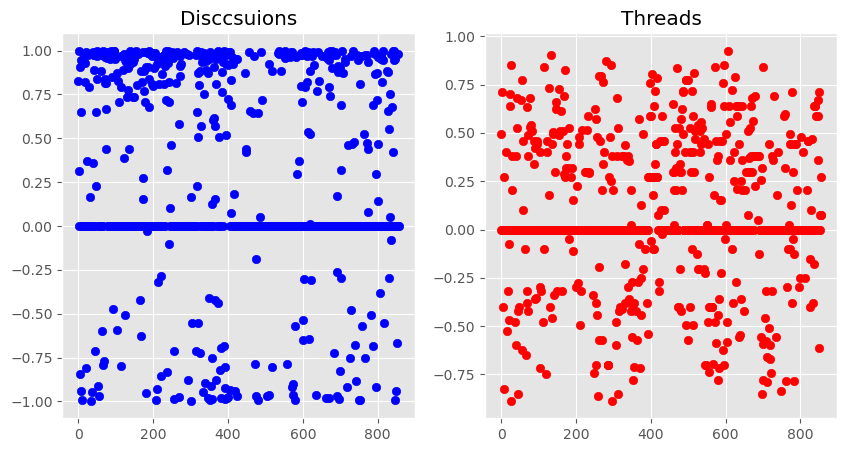

In [113]:
fig, axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(x=Vad['index'],y=Vad['comp_disc'],color = 'blue')
axs[0].set_title('Disccsuions')
axs[1].scatter(x=Vad['index'],y=Vad['comp_thread'],color = 'red')
axs[1].set_title('Threads')
plt.show()

# Even though the threads somewhat evenly distributed for negative and positive compund scores, 
# But discussions shows a clear shift towards positive sentiment indicating a positive market trend
# The postivity of threads is centered around a compound score of 0.50, 
# indicating a lesser positivity in the threads posted by public, 
# but this obivious as any person would come to social media to get the opinion of public, 
# they wont be fully positive or negative rather would have a half opinion, 
# they wouldnt come to social media nd post something if they already had formed an opinion on the matter
# The high density of values around extremities of the discussion scatter plot indicate,
# Clear opinions of redditors as they are replying to the person who posted the thread, and have clear opinion on the matter
# The half mindedness and clarity in thoughts of public can be seen here, gauging out emotions correctly

In [24]:
Vad['thread'].iloc[8]

'What the hell is wrong with indian market?'

In [25]:
Vad['Discussion'].iloc[8]

". Welcome to the bull run. Enjoy it as long as it lasts.. We too missed out on the rally due to not having enough money to buy stocks bro. Market is going up but my new stocks are going down since last week. Don't know why.. Everything follows law of averages. Indian markets may outperform for some amount of time but then reversal to mean will surely happen. The only problem is you can't predict when this will happen. Very unexpected moves. Reliance Power got debt free but not that up. No gradual upward moves. Daily some stocks are skyrocketing.\nFeels market is being manipulated.. Manipulated\nAlways have. Always has been. Always will be.. Wait for budget u will see. Result season and budget is around the corner. Things will be closer to their mean post these events. It's difficult to predict a market wise correction but stock wise correction follows earnings. Nifty is more likely to go into a time correction than a price correction. Completely uninformed opinion but once it reaches 